>>> Using device: cuda

Kích thước train (trước khi giới hạn): (809, 13) | Phân bố: Counter({0: 800, 1: 9})
Kích thước val: (4060, 13) | Phân bố: Counter({0: 4000, 1: 60})
Kích thước test: (6090, 13) | Phân bố: Counter({0: 6000, 1: 90})
Phân bố train (0=Normal,1=Anomaly): Counter({0: 800, 1: 9})
Phân bố test (0=Normal,1=Anomaly): Counter({0: 6000, 1: 90})

Các cột trong X_train:
['Source', 'Length', 'stNum', 'sqNum', 'goID', 'heartbeat', 'dif_stNum', 'dif_sqNum', 'Circuit breaker Open/Close Status', 'I-high VT', 'I-high VT- Tran', 'I-low VT- Tran', 'I-amongst-feeders']
Numeric columns: ['Length', 'heartbeat', 'I-high VT', 'I-high VT- Tran', 'I-low VT- Tran', 'I-amongst-feeders', 'sqNum']
Ordinal columns: ['Circuit breaker Open/Close Status']
Nominal columns: ['stNum', 'Source', 'dif_stNum', 'dif_sqNum', 'goID']

X_train_proc shape: (809, 90)
X_val_proc shape: (4060, 90)
X_test_proc shape: (6090, 90)

Unique y_train: [0 1]
Unique y_val: [0 1]
Unique y_test: [0 1]

Mô hình DNNOnePacket:


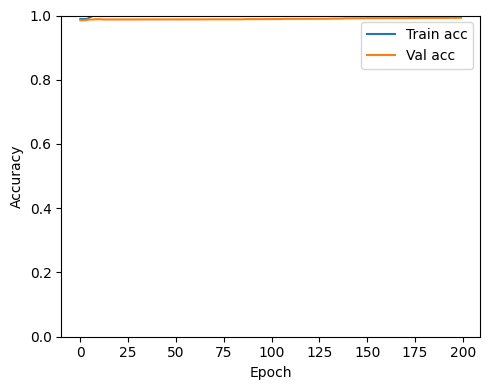

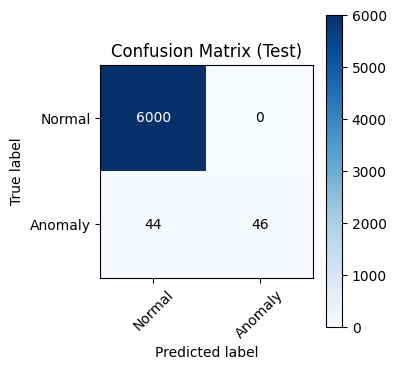

In [1]:
# ============================================================
# DNN 1-PACKET SUPERVISED CHO DATA GOOSE (PYTORCH)
# - Đọc từ label_pool / val_labeled_40 / test_labeled_60
# - Tiền xử lý bằng ColumnTransformer (num + ordinal + one-hot)
# - Huấn luyện DNN 1-packet: 16 → 32 → 64 → output
# - CHỌN MODEL THEO VAL F1-score (BINARY, pos_label=1)  <-- CHỈ SỬA PHẦN NÀY
# - In ra: F1-score(binary), AUROC, MCC                 <-- VÀ THÊM IN 3 CHỈ SỐ
# ============================================================

import math
import random
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    matthews_corrcoef
)

import matplotlib as mpl
import matplotlib.pyplot as plt

# --------------------------
# 0) Thiết lập matplotlib (tránh scientific notation)
# --------------------------
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.use_locale'] = False
mpl.rcParams['axes.formatter.use_mathtext'] = False

# --------------------------
# 1) Thiết lập device + SEED cho reproducibility
# --------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(">>> Using device:", device)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ---------------------------
# 1) Load three CSVs (already contain 'Label' 0/1 or string)
# ---------------------------
train_df = pd.read_csv("label_pool.csv")
val_df   = pd.read_csv("val_labeled_40.csv")
test_df  = pd.read_csv("test_labeled_60.csv")

# Split features/labels
FEATURES = [c for c in train_df.columns if c != "Label"]
X_train, y_train = train_df[FEATURES], train_df["Label"]
X_val,   y_val   = val_df[FEATURES],   val_df["Label"]
X_test,  y_test  = test_df[FEATURES],  test_df["Label"]

print("\nKích thước train (trước khi giới hạn):", X_train.shape, "| Phân bố:", Counter(y_train))
print("Kích thước val:",   X_val.shape,   "| Phân bố:", Counter(y_val))
print("Kích thước test:",  X_test.shape,  "| Phân bố:", Counter(y_test))

# --------------------------
# # 6b) GIỚI HẠN TRAIN CÒN 800 NORMAL + 4 ANOMALY
# (GIỮ NGUYÊN như code gốc: đang COMMENT OUT)
# --------------------------
# y_train_np_full = y_train.to_numpy()
# idx_all   = np.arange(len(y_train_np_full))
# idx_norm  = idx_all[y_train_np_full == 0]
# idx_anom  = idx_all[y_train_np_full == 1]
#
# n_norm_target = 800
# n_anom_target = 9
#
# if len(idx_norm) < n_norm_target:
#     print(f"[CẢNH BÁO] Số normal trong train chỉ có {len(idx_norm)}, < 800. Sẽ dùng {len(idx_norm)}.")
#     n_norm_target = len(idx_norm)
# if len(idx_anom) < n_anom_target:
#     print(f"[CẢNH BÁO] Số anomaly trong train chỉ có {len(idx_anom)}, < 4. Sẽ dùng {len(idx_anom)}.")
#     n_anom_target = len(idx_anom)
#
# sel_norm  = np.random.choice(idx_norm, size=n_norm_target, replace=False)
# sel_anom  = np.random.choice(idx_anom, size=n_anom_target, replace=False)
# sel_idx   = np.concatenate([sel_norm, sel_anom], axis=0)
#
# # Shuffle lại để tránh normal/anomaly bị block theo thứ tự
# np.random.shuffle(sel_idx)
#
# X_train = X_train.iloc[sel_idx].copy()
# y_train = y_train.iloc[sel_idx].copy()
#
# print("\n>>> Sau khi giới hạn TRAIN (800 normal + 9 anomaly):")
# print("Kích thước train:", X_train.shape)

print("Phân bố train (0=Normal,1=Anomaly):", Counter(y_train))
print("Phân bố test (0=Normal,1=Anomaly):", Counter(y_test))

# --------------------------
# 7) Tiền xử lý bằng ColumnTransformer
# --------------------------
print("\nCác cột trong X_train:")
print(list(X_train.columns))

# Pipeline cho numeric
num_transformer = Pipeline(steps=[
    ("num_scaler", StandardScaler())
])

# Chuẩn bị category cho ordinal (nếu cột tồn tại)
ord_cols = []
if "Circuit breaker Open/Close Status" in X_train.columns:
    ord_cols = ["Circuit breaker Open/Close Status"]
    cb_levels = [np.sort(X_train['Circuit breaker Open/Close Status'].unique()).tolist()]
    ord_transformer = Pipeline(steps=[
        ("encoder", OrdinalEncoder(
            categories=cb_levels,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ))
    ])
else:
    ord_transformer = None

# Danh sách nominal columns (nếu có)
nom_cols = [c for c in ['stNum', 'Source', 'dif_stNum', 'dif_sqNum', 'goID']
            if c in X_train.columns]

nom_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

transformers = []

# numeric features (tùy theo cột thực tế)
num_cols = [c for c in ['Length', 'heartbeat', 'I-high VT',
                        'I-high VT- Tran', 'I-low VT- Tran',
                        'I-amongst-feeders', 'sqNum']
            if c in X_train.columns]
if len(num_cols) > 0:
    transformers.append(("num_feature", num_transformer, num_cols))

if ord_transformer is not None and len(ord_cols) > 0:
    transformers.append(("ord_feature", ord_transformer, ord_cols))

if len(nom_cols) > 0:
    transformers.append(("nom_feature", nom_transformer, nom_cols))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder='drop'
)

print("Numeric columns:", num_cols)
print("Ordinal columns:", ord_cols)
print("Nominal columns:", nom_cols)

# Fit preprocessor trên TRAIN, sau đó transform cả train/val/test
reg = Pipeline(steps=[
    ("preprocessor", preprocessor)
])

reg.fit(X_train)
X_train_proc = reg.transform(X_train)
X_val_proc   = reg.transform(X_val)
X_test_proc  = reg.transform(X_test)

print("\nX_train_proc shape:", X_train_proc.shape)
print("X_val_proc shape:",   X_val_proc.shape)
print("X_test_proc shape:",  X_test_proc.shape)

# --------------------------
# 8) Chuẩn bị dữ liệu PyTorch
# --------------------------
X_train_np = X_train_proc.astype(np.float32)
X_val_np   = X_val_proc.astype(np.float32)
X_test_np  = X_test_proc.astype(np.float32)

y_train_np = y_train.to_numpy().astype(np.int64)
y_val_np   = y_val.to_numpy().astype(np.int64)
y_test_np  = y_test.to_numpy().astype(np.int64)

print("\nUnique y_train:", np.unique(y_train_np))
print("Unique y_val:",   np.unique(y_val_np))
print("Unique y_test:",  np.unique(y_test_np))

num_features = X_train_np.shape[1]
num_classes  = len(np.unique(y_train_np))  # = 2 (Normal vs Anomaly)

train_ds = TensorDataset(torch.from_numpy(X_train_np), torch.from_numpy(y_train_np))
val_ds   = TensorDataset(torch.from_numpy(X_val_np),   torch.from_numpy(y_val_np))
test_ds  = TensorDataset(torch.from_numpy(X_test_np),  torch.from_numpy(y_test_np))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

# --------------------------
# 9) Định nghĩa mô hình DNN 1-packet (GIỮ NGUYÊN)
# --------------------------
class DNNOnePacket(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)  # không dùng Softmax, CrossEntropyLoss sẽ lo
        )

    def forward(self, x):
        return self.net(x)

model = DNNOnePacket(num_features, num_classes).to(device)
print("\nMô hình DNNOnePacket:")
print(model)

# --------------------------
# 9.5) HÀM TÍNH METRICS (F1-binary, AUROC, MCC) — KHÔNG ĐỔI HYPERPARAM
# --------------------------
def compute_metrics_binary_from_logits(logits_cpu, y_true_cpu):
    """
    logits_cpu: torch.Tensor [N, 2] (cpu)
    y_true_cpu: torch.Tensor [N] (cpu)
    Return: f1_binary, auroc, mcc, y_pred_np
    """
    y_true_np = y_true_cpu.numpy()
    y_pred_np = torch.argmax(logits_cpu, dim=1).numpy()

    # F1-binary: pos_label=1 (Anomaly)
    f1_bin = f1_score(y_true_np, y_pred_np, average="binary", pos_label=1, zero_division=0)

    # MCC
    mcc = matthews_corrcoef(y_true_np, y_pred_np) if len(np.unique(y_true_np)) > 1 else 0.0

    # AUROC: dùng logit của class 1 làm score (giống code gốc ở TEST)
    if logits_cpu.shape[1] >= 2:
        scores = logits_cpu[:, 1].numpy()
    else:
        scores = logits_cpu[:, 0].numpy()

    try:
        auroc = roc_auc_score(y_true_np, scores) if len(np.unique(y_true_np)) > 1 else float("nan")
    except Exception:
        auroc = float("nan")

    return f1_bin, auroc, mcc, y_pred_np

# --------------------------
# 10) Huấn luyện model
#    * CHỌN BEST THEO VAL F1_BINARY (pos_label=1) *
#    (GIỮ NGUYÊN optimizer/lr/epochs/weight_decay/batch_size...)
# --------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

num_epochs = 200
best_val_f1_binary = -1.0
best_state         = None

train_acc_hist = []
val_acc_hist   = []

for epoch in range(1, num_epochs + 1):
    # ----- TRAIN -----
    model.train()
    running_loss = 0.0
    correct_tr, total_tr = 0, 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)                 # [B, num_classes]
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        _, preds = torch.max(logits, dim=1)
        correct_tr += (preds == yb).sum().item()
        total_tr   += yb.size(0)

    train_loss = running_loss / total_tr
    train_acc  = correct_tr / total_tr

    # ----- VALIDATION -----
    model.eval()
    correct_val, total_val = 0, 0
    all_val_logits = []
    all_val_labels = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            _, preds = torch.max(logits, dim=1)

            correct_val += (preds == yb).sum().item()
            total_val   += yb.size(0)

            all_val_logits.append(logits.cpu())
            all_val_labels.append(yb.cpu())

    val_acc = correct_val / total_val

    all_val_logits = torch.cat(all_val_logits, dim=0)   # [N,2]
    all_val_labels = torch.cat(all_val_labels, dim=0)   # [N]

    # === METRICS (VAL): F1-binary / AUROC / MCC ===
    val_f1_binary, val_auroc, val_mcc, _ = compute_metrics_binary_from_logits(all_val_logits, all_val_labels)

    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

    # === LƯU BEST STATE THEO VAL F1_BINARY (CHỈ THAY ĐỔI TIÊU CHÍ NÀY) ===
    if val_f1_binary > best_val_f1_binary:
        best_val_f1_binary = val_f1_binary
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch == 1 or epoch % 10 == 0:
        auroc_print = (val_auroc * 100) if (val_auroc == val_auroc) else float("nan")
        print(f"Epoch [{epoch}/{num_epochs}] "
              f"TrainLoss={train_loss:.4f} | TrainAcc={train_acc*100:.2f}% | "
              f"ValAcc={val_acc*100:.2f}% | "
              f"ValF1_bin={val_f1_binary*100:.2f}% | ValAUROC={auroc_print:.2f}% | ValMCC={val_mcc:.4f}")

print("\n>>> Best Val F1_binary = {:.2f}%".format(best_val_f1_binary * 100))

# Load lại best weights theo VALIDATION F1_binary
if best_state is not None:
    model.load_state_dict(best_state)

# --------------------------
# 11) In METRICS trên VAL (best checkpoint)
# --------------------------
model.eval()
val_logits_all = []
val_labels_all = []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        val_logits_all.append(logits.cpu())
        val_labels_all.append(yb)

val_logits_all = torch.cat(val_logits_all, dim=0)
val_labels_all = torch.cat(val_labels_all, dim=0)

val_f1_binary, val_auroc, val_mcc, val_pred_np = compute_metrics_binary_from_logits(val_logits_all, val_labels_all)
val_true_np = val_labels_all.numpy()

print("\n=== BEST CHECKPOINT METRICS (VALIDATION) ===")
print(f"F1-score (binary, VAL) = {val_f1_binary*100:.3f}%")
print(f"AUROC (VAL)            = {(val_auroc*100 if val_auroc==val_auroc else float('nan')):.3f}%")
print(f"MCC (VAL)              = {val_mcc:.4f}")

# --------------------------
# 12) Đánh giá trên TEST: In F1-binary, AUROC, MCC
#     (GIỮ nguyên phần confusion matrix/report nếu bạn muốn)
# --------------------------
model.eval()
all_logits = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        all_logits.append(logits.cpu())
        all_labels.append(yb)

all_logits = torch.cat(all_logits, dim=0)
all_labels = torch.cat(all_labels, dim=0)

test_f1_binary, test_auroc, test_mcc, y_pred_np = compute_metrics_binary_from_logits(all_logits, all_labels)
y_true_np = all_labels.numpy()

print("\n=== METRICS (TEST) ===")
print(f"F1-score (binary, TEST) = {test_f1_binary*100:.3f}%")
print(f"AUROC (TEST)            = {(test_auroc*100 if test_auroc==test_auroc else float('nan')):.3f}%")
print(f"MCC (TEST)              = {test_mcc:.4f}")

# (Optional) Giữ nguyên như code gốc: confusion matrix + report
print("\n=== Confusion Matrix (TEST) ===")
cm = confusion_matrix(y_true_np, y_pred_np)
print(cm)

print("\n=== Classification Report (TEST) ===")
print(classification_report(y_true_np, y_pred_np, digits=3))

# --------------------------
# 13) Vẽ đường accuracy train/val theo epoch (giống code gốc)
# --------------------------
plt.figure(figsize=(5, 4))
plt.plot(train_acc_hist, label="Train acc")
plt.plot(val_acc_hist,   label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------
# 14) Vẽ confusion matrix (heatmap) cho TEST (giống code gốc)
# --------------------------
plt.figure(figsize=(4, 4))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Test)")
plt.colorbar()

tick_marks = np.arange(num_classes)
if num_classes == 2:
    class_names = ["Normal", "Anomaly"]
else:
    class_names = [str(i) for i in range(num_classes)]

plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2.0 if cm.max() > 0 else 0.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()
